In [1]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

plt.style.use('bmh')

In [2]:
# 1. ĐỌC DỮ LIỆU TỪ FILE CSV
ten_file = "Laptop_PhongVu.csv"

try:
    df = pd.read_csv(ten_file)
    print(f"Đã tải thành công {len(df)} sản phẩm từ file '{ten_file}'")
except FileNotFoundError:
    print(f"Không tìm thấy file '{ten_file}'")
    exit()

# 2. LÀM SẠCH VÀ CHUẨN BỊ DỮ LIỆU
def lam_sach_gia(gia_text):
    if pd.isna(gia_text) or str(gia_text).strip() == "Liên hệ": return 0
    gia_clean = re.sub(r"[^\d]", "", str(gia_text))
    return int(gia_clean) if gia_clean else 0

def lay_thuong_hieu(ten_sp):
    tu_khoa = str(ten_sp).upper().split()
    if not tu_khoa: return "UNKNOWN"
    if tu_khoa[0] == "LAPTOP" and len(tu_khoa) > 1: return tu_khoa[1]
    if "MACBOOK" in tu_khoa[0]: return "APPLE"
    return tu_khoa[0]

def gan_nhan_phan_khuc(gia):
    if gia < 15000000: return "Phổ thông (< 15 Triệu)"
    elif 15000000 <= gia <= 25000000: return "Tầm trung (15 - 25 Triệu)"
    else: return "Cao cấp (> 25 Triệu)"

def convert_storage_to_gb(storage_str):
    storage_str = str(storage_str).upper()
    if 'TB' in storage_str:
        val = re.sub(r'[^\d]', '', storage_str)
        return int(val) * 1024 if val else 0
    elif 'GB' in storage_str:
        val = re.sub(r'[^\d]', '', storage_str)
        return int(val) if val else 0
    return 0

def phan_loai_card(vga_str):
    vga_str = str(vga_str).upper()
    tu_khoa_card_roi = ['RTX', 'GTX', 'RX ', 'RADEON PRO', 'ARC']
    if any(tu_khoa in vga_str for tu_khoa in tu_khoa_card_roi):
        return 'Card Rời'
    return 'Card Onboard'

# Xử lý Giá
df["Giá gốc (VNĐ)"] = df["Giá gốc"].apply(lam_sach_gia)
df["Giá hiện tại (VNĐ)"] = df["Giá hiện tại"].apply(lam_sach_gia)

# Lọc máy hợp lệ (Loại bỏ các máy không có giá)
df_hop_le = df[df["Giá hiện tại (VNĐ)"] > 0].copy()
if df_hop_le.empty:
    print("Không có sản phẩm nào có giá hợp lệ.")
    exit()

# Thêm các cột phân loại và thông số
df_hop_le['Thương hiệu'] = df_hop_le['Tên sản phẩm'].apply(lay_thuong_hieu)
df_hop_le['Tên rút gọn'] = df_hop_le['Tên sản phẩm'].apply(lambda x: str(x)[:45] + '...' if len(str(x)) > 45 else str(x))
df_hop_le['Phân khúc'] = df_hop_le['Giá hiện tại (VNĐ)'].apply(gan_nhan_phan_khuc)

# Tính toán mức giảm giá
df_hop_le["Tiền giảm (VNĐ)"] = df_hop_le["Giá gốc (VNĐ)"] - df_hop_le["Giá hiện tại (VNĐ)"]
df_hop_le["% Giảm giá"] = df_hop_le.apply(
    lambda row: (row["Tiền giảm (VNĐ)"] / row["Giá gốc (VNĐ)"]) * 100 if row["Giá gốc (VNĐ)"] > 0 else 0, axis=1
)

# Xử lý RAM, SSD và Card màn hình
df_hop_le['RAM (GB)'] = df_hop_le['RAM'].astype(str).str.replace('GB', '', case=False).str.strip()
df_hop_le['RAM (GB)'] = pd.to_numeric(df_hop_le['RAM (GB)'], errors='coerce')
df_hop_le['SSD (GB)'] = df_hop_le['SSD'].apply(convert_storage_to_gb)
df_hop_le['Loại Card'] = df_hop_le['VGA/GPU'].apply(phan_loai_card)

# 3. PHÂN TÍCH VÀ THỐNG KÊ NHANH
print("\nBÁO CÁO THỐNG KÊ NHANH")
print(f"Tổng số máy có giá công khai: {len(df_hop_le)}/{len(df)} máy")
print(f"Mức giá trung bình: {df_hop_le['Giá hiện tại (VNĐ)'].mean():,.0f} VNĐ")

may_dat_nhat = df_hop_le.loc[df_hop_le["Giá hiện tại (VNĐ)"].idxmax()]
print(f"\n[MÁY CAO CẤP NHẤT]\n   - {may_dat_nhat['Tên sản phẩm']} \n   - Giá: {may_dat_nhat['Giá hiện tại (VNĐ)']:,.0f} VNĐ")

may_re_nhat = df_hop_le.loc[df_hop_le["Giá hiện tại (VNĐ)"].idxmin()]
print(f"\n[MÁY PHỔ THÔNG NHẤT]\n   - {may_re_nhat['Tên sản phẩm']} \n   - Giá: {may_re_nhat['Giá hiện tại (VNĐ)']:,.0f} VNĐ")

df_khuyen_mai = df_hop_le[df_hop_le["Tiền giảm (VNĐ)"] > 0]
if not df_khuyen_mai.empty:
    best_deal = df_khuyen_mai.loc[df_khuyen_mai["% Giảm giá"].idxmax()]
    print(f"\n[DEAL SALE SỐC NHẤT HIỆN TẠI]")
    print(f"   - Tên máy: {best_deal['Tên sản phẩm']}")
    print(f"   - Đang bán: {best_deal['Giá hiện tại (VNĐ)']:,.0f} VNĐ (Gốc: {best_deal['Giá gốc (VNĐ)']:,.0f} VNĐ)")
    print(f"   - Mức giảm: {best_deal['% Giảm giá']:.1f}% (-{best_deal['Tiền giảm (VNĐ)']:,.0f} VNĐ)")

Đã tải thành công 50 sản phẩm từ file 'Laptop_PhongVu.csv'

BÁO CÁO THỐNG KÊ NHANH
Tổng số máy có giá công khai: 50/50 máy
Mức giá trung bình: 30,126,000 VNĐ

[MÁY CAO CẤP NHẤT]
   - Laptop Asus TUF Gaming A14 FA401EA-RG034W 
   - Giá: 62,590,000 VNĐ

[MÁY PHỔ THÔNG NHẤT]
   - Laptop HP 240R G9 - AX3C6AT 
   - Giá: 14,990,000 VNĐ

[DEAL SALE SỐC NHẤT HIỆN TẠI]
   - Tên máy: Laptop Lenovo LOQ Essential 15ARP10E - 83S0000DVN
   - Đang bán: 24,990,000 VNĐ (Gốc: 35,990,000 VNĐ)
   - Mức giảm: 30.6% (-11,000,000 VNĐ)


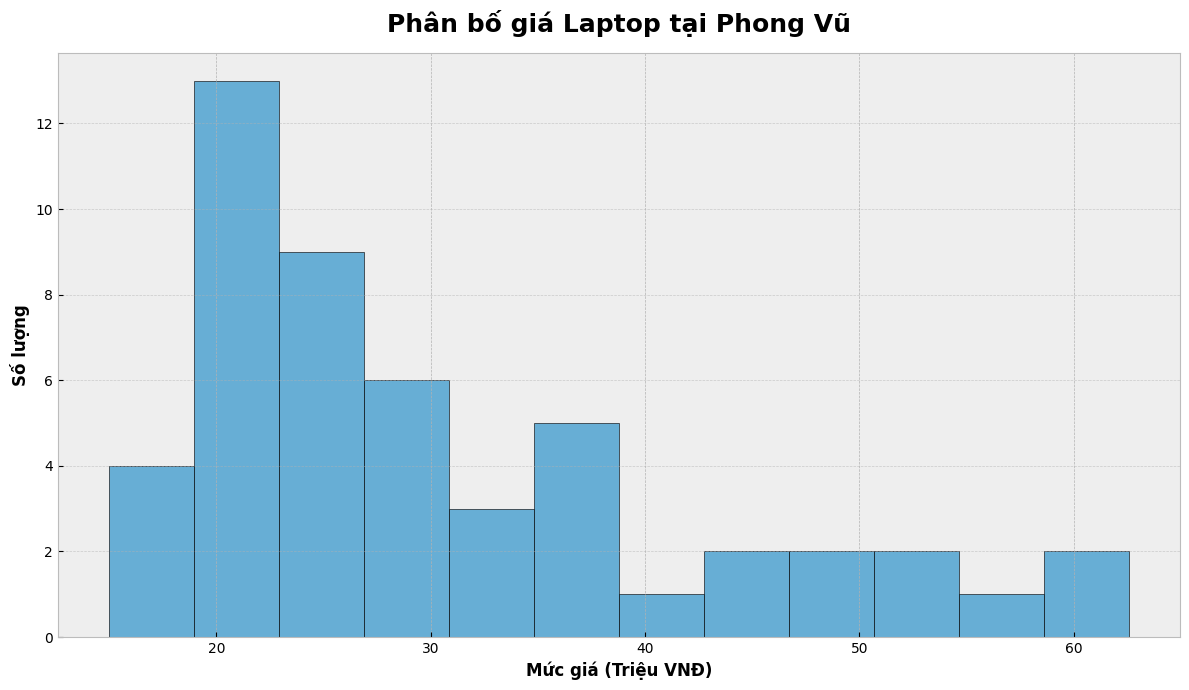

In [3]:
# 4. TRỰC QUAN HÓA DỮ LIỆU (MATPLOTLIB)

# BIỂU ĐỒ 1: PHÂN BỐ GIÁ TỔNG QUAN
prices = df_hop_le['Giá hiện tại (VNĐ)'] / 1_000_000

plt.figure(figsize=(12, 7))
plt.hist(prices, bins=12, color='#4FA3D1', edgecolor='black', alpha=0.85)

plt.title('Phân bố giá Laptop tại Phong Vũ', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Mức giá (Triệu VNĐ)', fontsize=12, fontweight='bold')
plt.ylabel('Số lượng', fontsize=12, fontweight='bold')

# Bật lưới ngang kẻ đứt quãng để dễ gióng số lượng
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

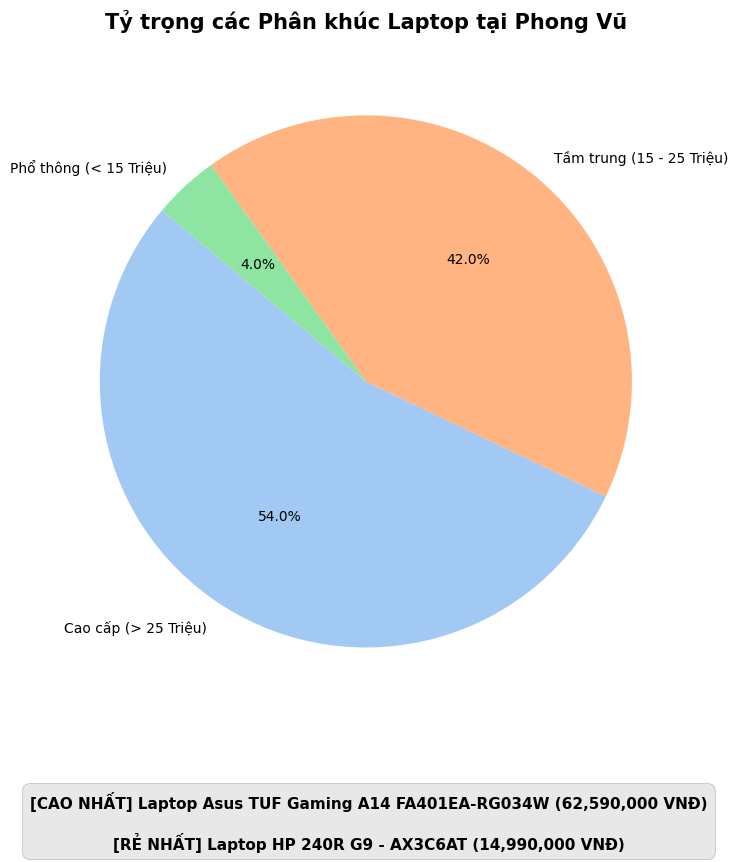

In [4]:
# BIỂU ĐỒ 2: PHÂN KHÚC GIÁ
plt.figure(figsize=(9, 9)) 

phan_khuc_counts = df_hop_le['Phân khúc'].value_counts()
plt.pie(phan_khuc_counts, labels=phan_khuc_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))

plt.title('Tỷ trọng các Phân khúc Laptop tại Phong Vũ', fontsize=15, fontweight='bold', pad=15)

# Thêm hộp thông tin máy đắt nhất và rẻ nhất ở dưới đáy biểu đồ
thong_tin_chu = (
    f"[CAO NHẤT] {may_dat_nhat['Tên rút gọn']} ({may_dat_nhat['Giá hiện tại (VNĐ)']:,.0f} VNĐ)\n\n"
    f"[RẺ NHẤT] {may_re_nhat['Tên rút gọn']} ({may_re_nhat['Giá hiện tại (VNĐ)']:,.0f} VNĐ)"
)
plt.figtext(0.5, 0.05, thong_tin_chu, ha="center", fontsize=11, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgrey", edgecolor="gray", alpha=0.5))

plt.tight_layout()
# Nới thêm khoảng trống phía dưới cùng để không bị lẹm mất hộp thông tin
plt.subplots_adjust(bottom=0.2) 
plt.show()

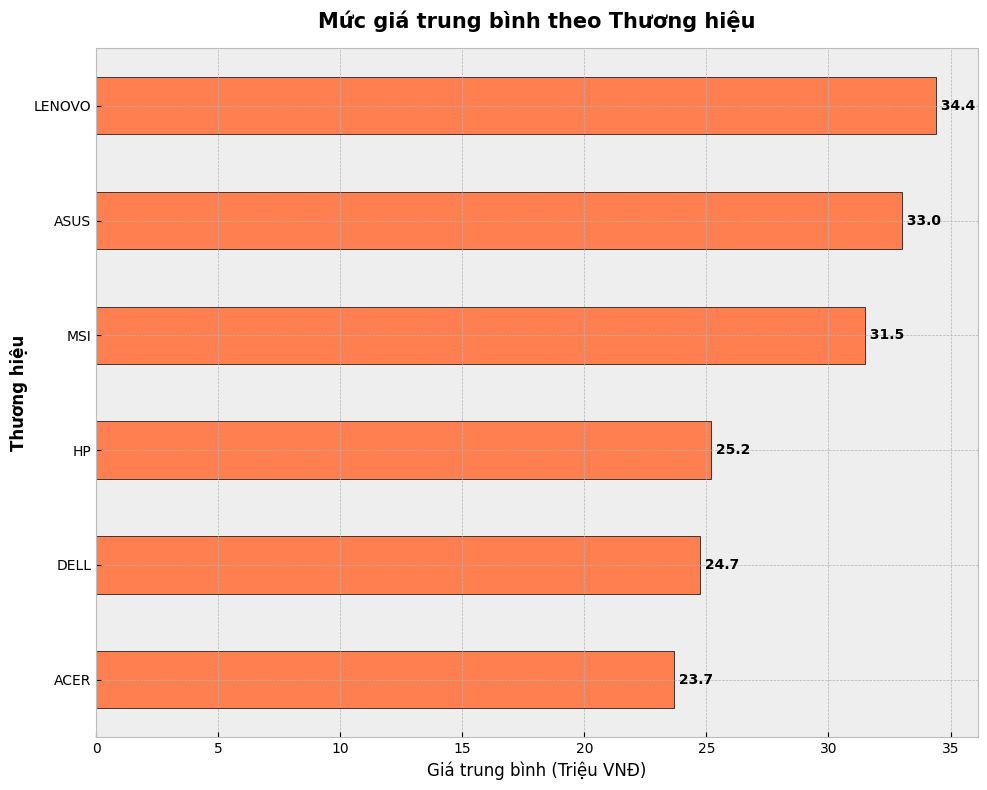

In [5]:
# BIỂU ĐỒ 3: GIÁ TRUNG BÌNH THEO THƯƠNG HIỆU 
gia_tb_hang = df_hop_le.groupby('Thương hiệu')['Giá hiện tại (VNĐ)'].mean().sort_values(ascending=True) / 1000000

plt.figure(figsize=(10, 8))
gia_tb_hang.plot(kind='barh', color='coral', edgecolor='black')

plt.title('Mức giá trung bình theo Thương hiệu', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Giá trung bình (Triệu VNĐ)', fontsize=12) 
plt.ylabel('Thương hiệu', fontsize=12, fontweight='bold')

# Ghi mức giá trung bình trực tiếp lên đuôi mỗi thanh ngang
for index, value in enumerate(gia_tb_hang):
    plt.text(value, index, f" {value:,.1f}", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

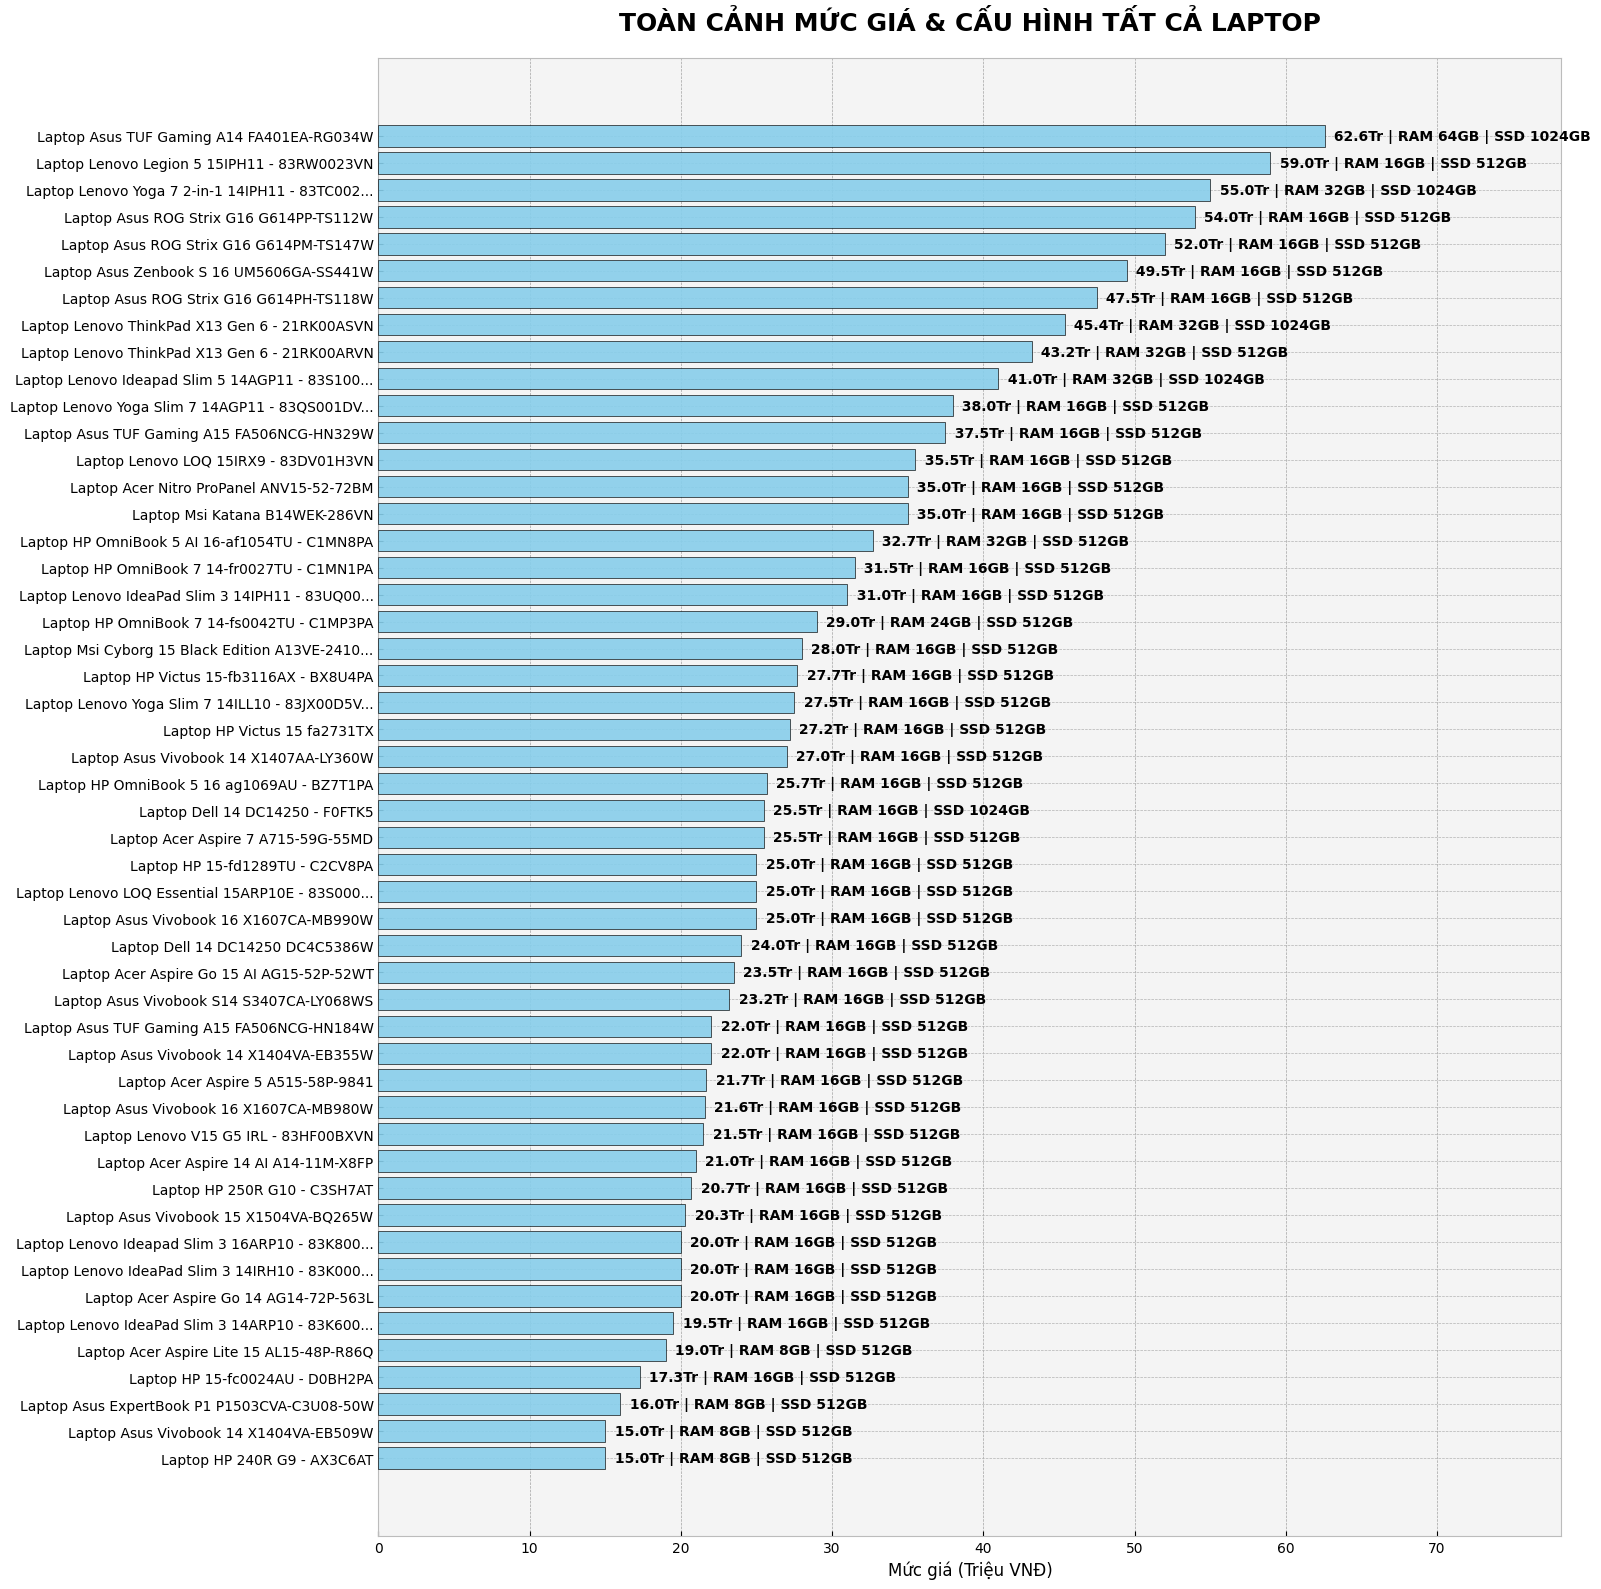

In [6]:
# BIỂU ĐỒ 4: TỔNG QUAN GIÁ VÀ CẤU HÌNH TOÀN BỘ SẢN PHẨM
df_sorted = df_hop_le.sort_values(by='Giá hiện tại (VNĐ)', ascending=True).reset_index(drop=True)

plt.figure(figsize=(16, 16))
plt.gca().set_facecolor('#f4f4f4')
plt.grid(axis='x', linestyle='--', alpha=0.7, color='gray', zorder=0)

prices = df_sorted['Giá hiện tại (VNĐ)'] / 1000000
colors = df_sorted['Loại Card'].map({'Card Rời': 'salmon', 'Card Onboard': 'skyblue'})

bars = plt.barh(df_sorted['Tên rút gọn'], prices, color=colors, edgecolor='black', alpha=0.9, zorder=3)

# Ghi thông tin (Mức giá, RAM, SSD) trực tiếp lên đuôi mỗi thanh biểu đồ
for bar, ram, ssd in zip(bars, df_sorted['RAM (GB)'], df_sorted['SSD (GB)']):
    thong_tin = f" {bar.get_width():.1f}Tr | RAM {ram:.0f}GB | SSD {ssd:.0f}GB"
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
             thong_tin, va='center', fontsize=10, fontweight='bold', color='black')

plt.title('TOÀN CẢNH MỨC GIÁ & CẤU HÌNH TẤT CẢ LAPTOP', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Mức giá (Triệu VNĐ)', fontsize=12)
plt.ylabel('')

plt.xlim(0, prices.max() * 1.25) 
plt.tight_layout()
plt.show()

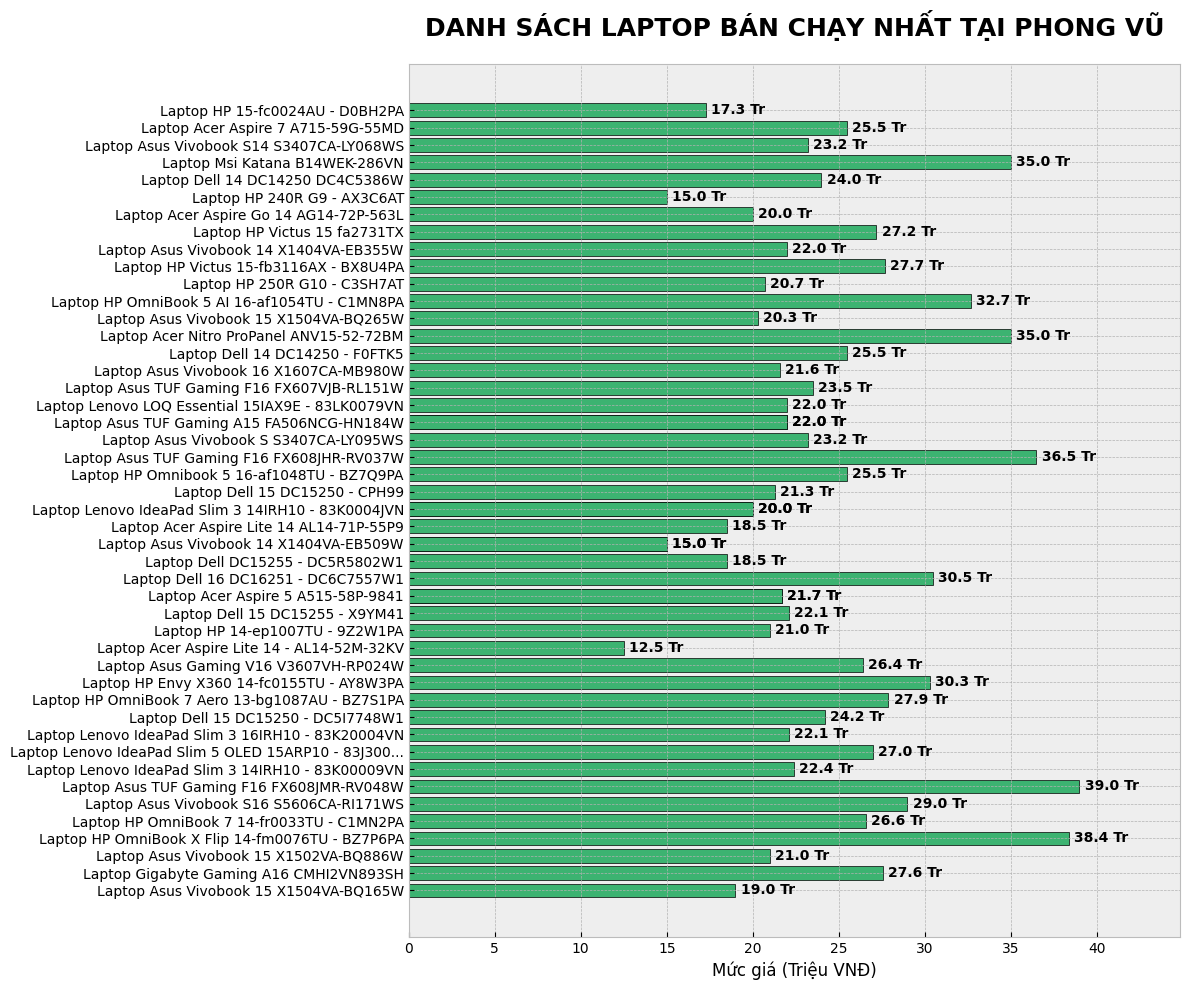

In [7]:
# BIỂU ĐỒ 5: DANH SÁCH LAPTOP BÁN CHẠY NHẤT VÀ MỨC GIÁ
df_bc = pd.read_csv('Laptop_BanChay_PhongVu.csv') 
df_bc["Giá hiện tại (VNĐ)"] = df_bc["Giá hiện tại"].apply(lam_sach_gia)
df_bc_hop_le = df_bc[df_bc["Giá hiện tại (VNĐ)"] > 0].copy()
all_bc = df_bc_hop_le.iloc[::-1]  
    
plt.figure(figsize=(12, 10)) 
prices_bc = all_bc['Giá hiện tại (VNĐ)'] / 1000000
ten_rut_gon_bc = all_bc['Tên sản phẩm'].apply(lambda x: str(x)[:50] + '...' if len(str(x)) > 50 else str(x))

bars_bc = plt.barh(ten_rut_gon_bc, prices_bc, color='mediumseagreen', edgecolor='black')

plt.title('DANH SÁCH LAPTOP BÁN CHẠY NHẤT TẠI PHONG VŨ', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Mức giá (Triệu VNĐ)', fontsize=12)
plt.ylabel('')
        
# Ghi mức giá trực tiếp lên đuôi mỗi thanh biểu đồ
for bar in bars_bc:
    xval = bar.get_width()
    plt.text(xval + 0.3, bar.get_y() + bar.get_height()/2, 
             f"{xval:,.1f} Tr", ha='left', va='center', fontsize=10, fontweight='bold')

plt.xlim(0, prices_bc.max() * 1.15) 
plt.tight_layout()
plt.show()

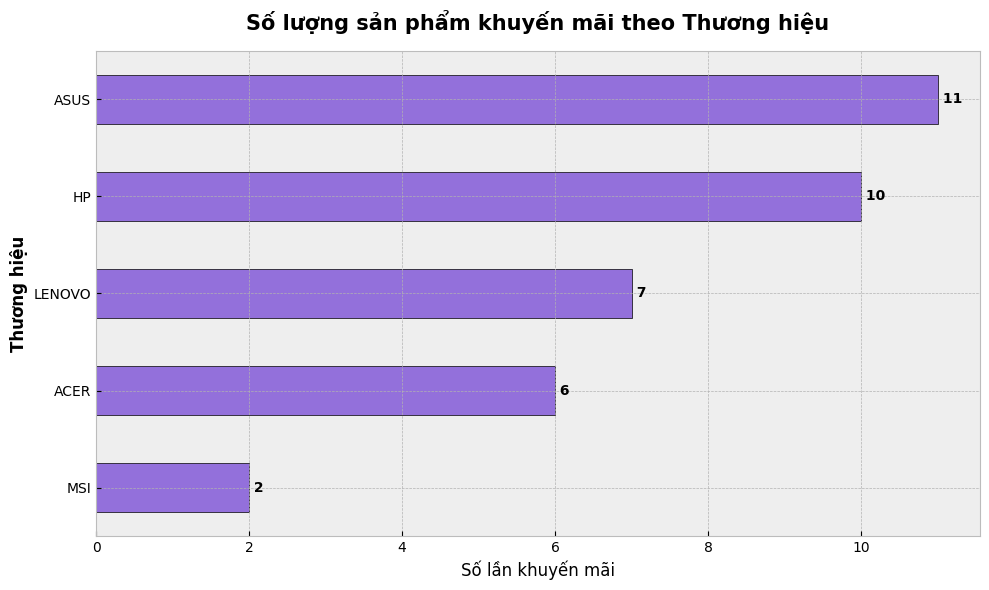

In [8]:
# BIỂU ĐỒ 6: HÃNG NÀO HAY KHUYẾN MÃI NHẤT? (Tần suất)
if not df_khuyen_mai.empty:
    # Đếm số lượng sản phẩm/lần khuyến mãi theo từng hãng
    tan_suat_km = df_khuyen_mai["Thương hiệu"].value_counts().sort_values(ascending=True)
    
    plt.figure(figsize=(10, 6))
    tan_suat_km.plot(kind='barh', color='mediumpurple', edgecolor='black')
    
    plt.title('Số lượng sản phẩm khuyến mãi theo Thương hiệu', fontsize=15, fontweight='bold', pad=15)
    plt.xlabel('Số lần khuyến mãi', fontsize=12) 
    plt.ylabel('Thương hiệu', fontsize=12, fontweight='bold')
    
    # Ghi số lượng trực tiếp lên đuôi mỗi thanh biểu đồ
    for index, value in enumerate(tan_suat_km):
        plt.text(value, index, f" {int(value)}", va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

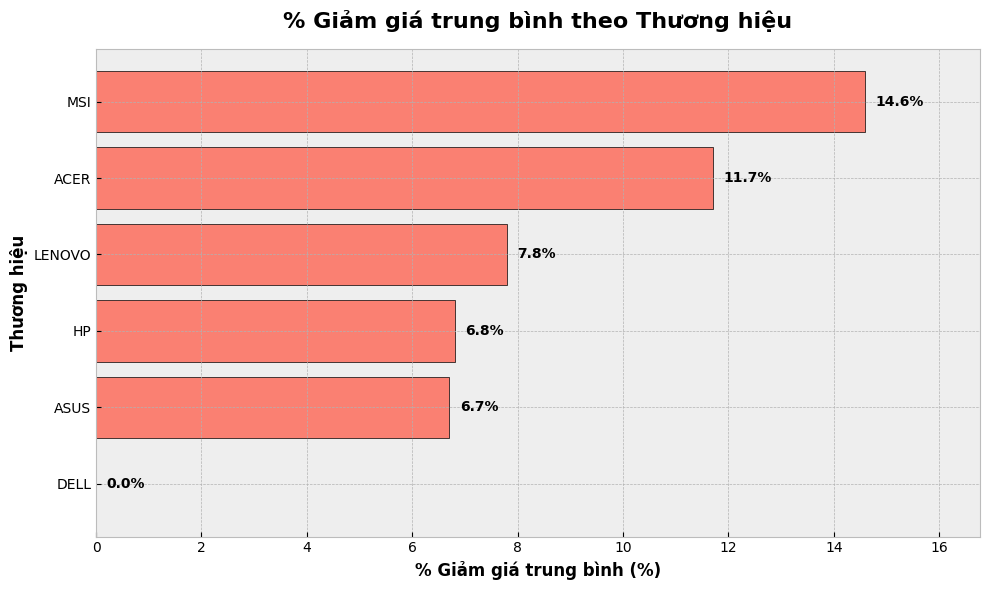

In [9]:
# BIỂU ĐỒ 7: % GIẢM GIÁ THEO HÃNG
plt.figure(figsize=(10, 6))

giam_tb_hang = df_hop_le.groupby('Thương hiệu')['% Giảm giá'].mean().sort_values(ascending=True)
bars_h = plt.barh(giam_tb_hang.index, giam_tb_hang.values, color='salmon', edgecolor='black')

plt.title('% Giảm giá trung bình theo Thương hiệu', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('% Giảm giá trung bình (%)', fontsize=12, fontweight='bold')
plt.ylabel('Thương hiệu', fontsize=12, fontweight='bold')

# Ghi % giảm giá trực tiếp lên đuôi mỗi thanh ngang
for bar in bars_h:
    xval = bar.get_width()
    plt.text(xval + 0.2, bar.get_y() + bar.get_height()/2, 
             f"{xval:.1f}%", ha='left', va='center', fontsize=10, fontweight='bold')

plt.xlim(0, giam_tb_hang.max() * 1.15)
plt.tight_layout()
plt.show()

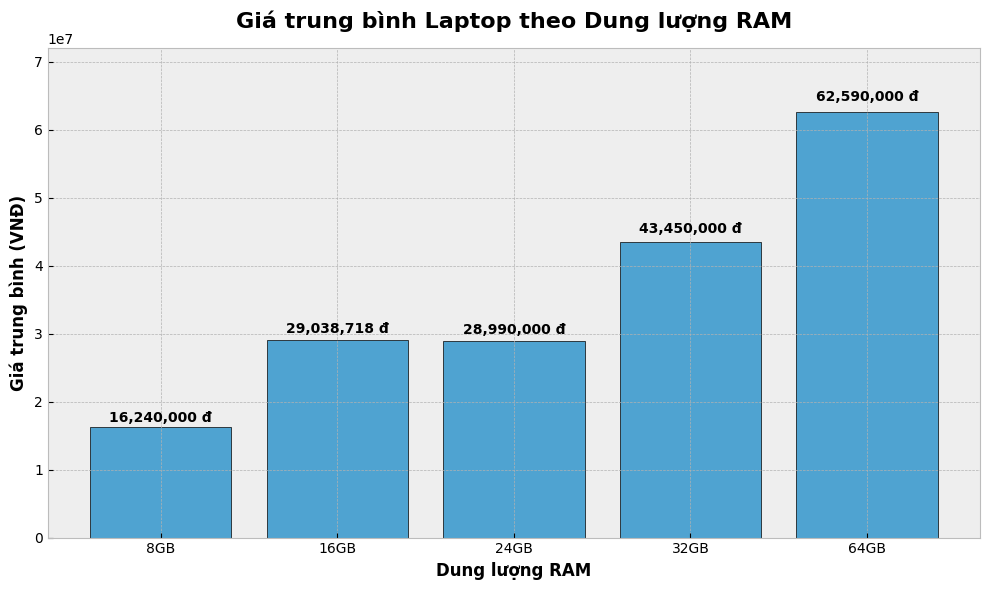

In [10]:
# BIỂU ĐỒ 8: GIÁ TRUNG BÌNH THEO RAM
plt.figure(figsize=(10, 6))

gia_tb_ram = df_hop_le.dropna(subset=['RAM (GB)']).groupby('RAM (GB)')['Giá hiện tại (VNĐ)'].mean().reset_index()
gia_tb_ram = gia_tb_ram.sort_values(by='RAM (GB)')
nhan_ram = gia_tb_ram['RAM (GB)'].astype(int).astype(str) + 'GB'

bars = plt.bar(nhan_ram, gia_tb_ram['Giá hiện tại (VNĐ)'], color='#4FA3D1', edgecolor='black')

plt.title('Giá trung bình Laptop theo Dung lượng RAM', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Dung lượng RAM', fontsize=12, fontweight='bold')
plt.ylabel('Giá trung bình (VNĐ)', fontsize=12, fontweight='bold')

# Ghi mức giá trực tiếp lên đầu mỗi cột dọc
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02), 
             f"{yval:,.0f} đ", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim(0, gia_tb_ram['Giá hiện tại (VNĐ)'].max() * 1.15)
plt.tight_layout()
plt.show()